<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula04_pesquisadedadosmensaisdeservicosPMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CURSO: Análise de Conjuntura usando Python - Análise Macro<br>
AULA: Coleta e tratamento de dados da Pesquisa Mensal de Serviços<br>
INFORMAÇÕES: saiba mais sobre a Pesquisa Mensal de Serviços (PMS/IBGE) no link https://www.ibge.gov.br/estatisticas/economicas/servicos/9229-pesquisa-mensal-de-servicos.html <br>
AUTOR: Fernando da Silva/Cientista de dados

# Bibliotecas

In [ ]:
# Instalar bibliotecas
!pip install sidrapy

# Importar as bibliotecas
import sidrapy as sidra
import pandas as pd
import seaborn as sns

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Dados

In [ ]:
# Coleta de dados
dados_brutos = sidra.get_table(
    table_code = "8162",
    territorial_level = "1",
    ibge_territorial_code = "all",
    variable = "11623,11624,11625,11626",
    classifications = {
        "11046": "56725,56726",
        "12355": "107071"
        },
    period = "all"
    )
dados_brutos

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N,D5C,D5N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,Variável (Código),Variável,Tipos de índice (Código),Tipos de índice,Atividades de serviços (Código),Atividades de serviços
1,1,Brasil,,,...,1,Brasil,201101,janeiro 2011,11623,"PMS - Variação mês/mês imediatamente anterior,...",56725,Índice de receita nominal de serviços,107071,Total
2,1,Brasil,,,...,1,Brasil,201101,janeiro 2011,11623,"PMS - Variação mês/mês imediatamente anterior,...",56726,Índice de volume de serviços,107071,Total
3,1,Brasil,,,...,1,Brasil,201101,janeiro 2011,11624,PMS - Variação mês/mesmo mês do ano anterior (...,56725,Índice de receita nominal de serviços,107071,Total
4,1,Brasil,,,...,1,Brasil,201101,janeiro 2011,11624,PMS - Variação mês/mesmo mês do ano anterior (...,56726,Índice de volume de serviços,107071,Total
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,1,Brasil,2,%,6.3,1,Brasil,202207,julho 2022,11624,PMS - Variação mês/mesmo mês do ano anterior (...,56726,Índice de volume de serviços,107071,Total
1109,1,Brasil,2,%,16.4,1,Brasil,202207,julho 2022,11625,PMS - Variação acumulada no ano (em relação ao...,56725,Índice de receita nominal de serviços,107071,Total
1110,1,Brasil,2,%,8.5,1,Brasil,202207,julho 2022,11625,PMS - Variação acumulada no ano (em relação ao...,56726,Índice de volume de serviços,107071,Total
1111,1,Brasil,2,%,16.4,1,Brasil,202207,julho 2022,11626,PMS - Variação acumulada em 12 meses (em relaç...,56725,Índice de receita nominal de serviços,107071,Total


In [ ]:
# Tratamento de dados
dados = (
    dados_brutos.rename(columns = dados_brutos.iloc[0])
    .rename( #renomeando as colunas
        columns = {
            "Mês (Código)": "data",
            "Variável": "taxas",
            "Tipos de índice": "indice",
            "Valor": "valor"
            }
            )
    .filter(items = ["data", "taxas", "indice", "valor"], axis = "columns")
    .query("valor not in ['...', 'Valor']") #para remover valores citados
    .assign(
        data = lambda x: pd.to_datetime(x.data, format = "%Y%m"),
        valor = lambda x: x.valor.astype(float)  #para alterar o tipo de dado
        )
    .replace(   #funcao para recodificar o tipo de dados e renomear as colunas
        to_replace = {
            "taxas": {
                "PMS - Variação mês/mês imediatamente anterior, com ajuste sazonal (M/M-1)": "Var. % margem",
                "PMS - Variação mês/mesmo mês do ano anterior (M/M-12)": "Var. % interanual",
                "PMS - Variação acumulada no ano (em relação ao mesmo período do ano anterior)": "Var. % acum. ano",
                "PMS - Variação acumulada em 12 meses (em relação ao período anterior de 12 meses)": "Var. % anual"
                },
            "indice": {
                "Índice de receita nominal de serviços": "Receita Nominal",
                "Índice de volume de serviços": "Volume"
                }
                }
             )
)
dados

,data,taxas,indice,valor
9,2011-02-01,Var. % margem,Receita Nominal,1.4
10,2011-02-01,Var. % margem,Volume,0.2
17,2011-03-01,Var. % margem,Receita Nominal,1.2
18,2011-03-01,Var. % margem,Volume,-0.4
25,2011-04-01,Var. % margem,Receita Nominal,1.5
...,...,...,...,...
1108,2022-07-01,Var. % interanual,Volume,6.3
1109,2022-07-01,Var. % acum. ano,Receita Nominal,16.4
1110,2022-07-01,Var. % acum. ano,Volume,8.5
1111,2022-07-01,Var. % anual,Receita Nominal,16.4


# Visualização de dados

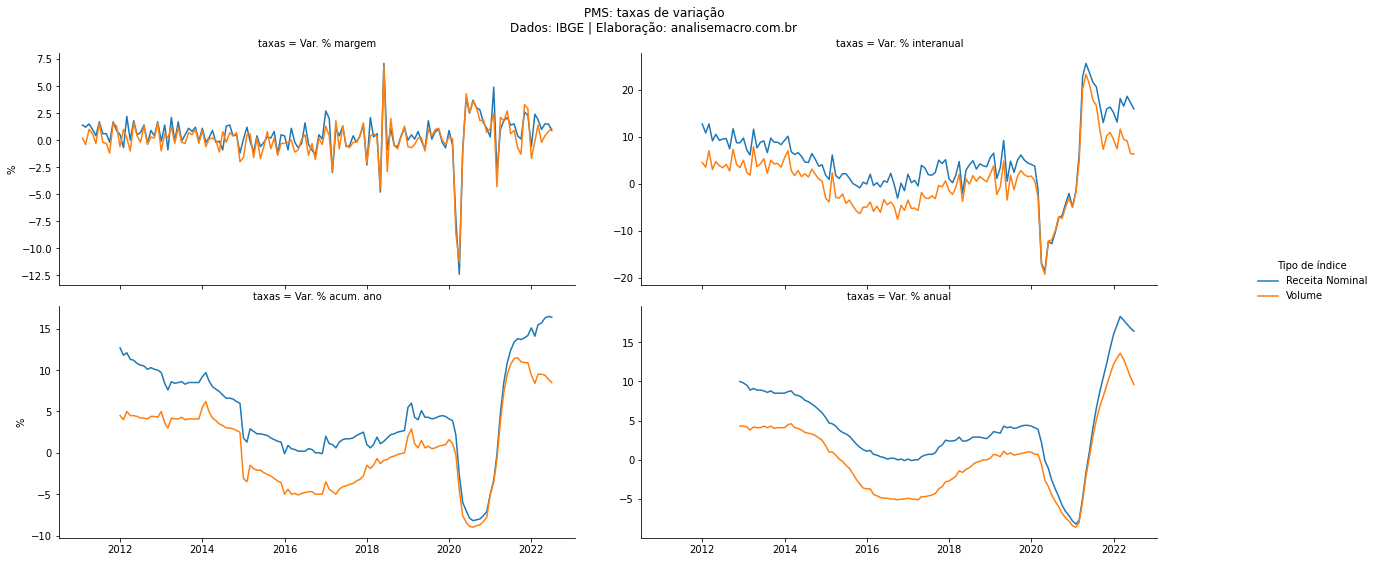

In [ ]:
# Gráfico de linha
grafico = sns.relplot( #criacao do obejto grafico
    data = dados,
    x = "data",
    y = "valor",
    kind = "line",
    hue = "indice", #nivel de agrupamento dos dados
    col = "taxas", #desagregacao das taxas
    col_wrap = 2,  #para separar em duas linhas
    facet_kws = {"sharey": False} #para definir a mesma escala para todos os graficos
    )

grafico.fig.set_figwidth(20) #para definir a largura do grafico
grafico.fig.set_figheight(8) #para definir a a altura do grafico
grafico.fig.subplots_adjust(top=0.9)
grafico.fig.suptitle("PMS: taxas de variação\nDados: IBGE | Elaboração: analisemacro.com.br")
grafico.set_axis_labels("", "%")
grafico._legend.set_title("Tipo de índice")